# Final Exam - DS4DS

## General information

This is the problem description for the final project of the course *"Data Science for Dynamical Systems"* (Winter Term 2025/26)
- February 24th or March 10th

Submission before your presentation (via moodle)
- your slides
- your program code

### Grading
For your assessment, we will grade the following parts of your final project
- quality and clarity of the presentation
- your modeling choices and the reasons for your choices
- your approach to data preparation and analysis
- your technical realization (e.g., choice of algorithms, implementation, ...)
- the results as well as their presentation / visualization
- analysis and interpretation of the reseults
- your replies in the consecutive Q&A session

Each participant will be graded invididually, and we expect everyone to participate in the preparation as well as the presentation.

### Tasks
Below, you will find two tasks. One is concerned with data-driven prediction of a large-scale system, the second one with data-driven control of an ODE.

#### IMPORTANT: out of these, you should only select **one** task as your project!

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Task 1: Prediction of reduced PlanetSWE

##### **Dataset:**
* We reduced the PlanetSWE dataset (see https://polymathic-ai.org/the_well/datasets/planetswe/ for details on the original dataset), in the following way:
    * Downsampling of the $256 \times 512$ data images to $128 \times 256$ via mean-pooling.
    * Removing the "height" data-field, such that only the velocity vector field remains. (meaning each time-slice is of shape $2 \times 128 \times 256$)
    * Retaining only the first $1008$ time steps of the original $3024$.
    * Reducing to only $20$ of the $40$ trajectories.
* We have the time scale $(t_0,t_e)=(0,1008)$, with $dt$ of $1$ hour, thus $24$ timesteps for one day and thus $1008/24 = 42$ days.

**Loading**
* The dataset is split into several .zip files, many `train_[...].zip` and one `test_16_19.zip`, containing .npy files.
* **Each .npy file is one entire trajectory!**
* Loading one trajectory, for example the first `X = np.load({path_to_folder}/planetswe_IC00_s1)`, gives you a numpy array of shape `(1008, 2, 128, 256)`.

*Animation of the velocity-magnitude for $200$ time steps, projected onto a sphere:*

![simulation](planetswe_200.gif)

---

#### **Task:**
* **Train a model using this dataset that predicts the system behavior as accurately as possible.**
* You can choose any model presented in the lecture or exercises.

**Initialization**
* As initial condition take the 24th time-step (beginning of day 2, `X[24, :, :, :]`)
* If you decide to use a model with memory, you may use the entire day 1 for initialization, time steps $0$ to $23$: `X[0:24, :, :, :]`

**Train & Test**
* **Only use the trajectories in the `train_[...].zip` for training.**
* Use `test_16_19.zip` for testing.
* The error should be measured as the MSE between the predicted state and the ground truh (i.e., the given data).

---

**Regarding higher computational requirements**
* If you have a CUDA or ROCm capable GPU locally, consider installing PyTorch with the respective compute platform (https://pytorch.org/get-started/locally/)
* You may also use TUDo's LiDO3 cluster (https://lido.itmc.tu-dortmund.de/)
* Otherwise, consider dimensionality reduction techniques, or further downsampling of the data

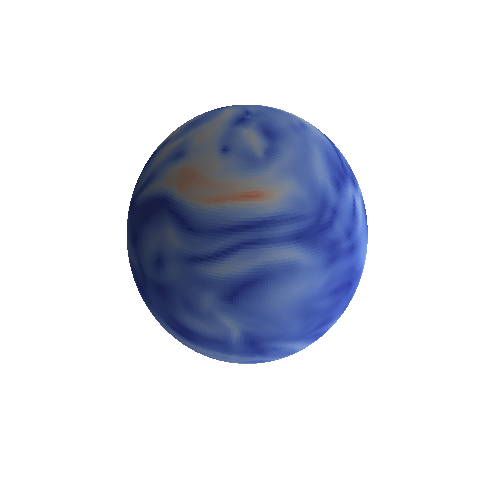

In [2]:
##### EXAMPLE FOR 3D MAPPING #####

velocity = np.load("example_time_step.npy") # equal to X[0] of the trajectory in file planetswe_IC00_s1.npy
# ----------------------------------------------------------------------------------------------------

# Velocity components
v_theta = velocity[0]
v_phi   = velocity[1]

# Define angular grids
n_theta = v_theta.shape[0]
n_phi   = v_theta.shape[1]

theta = np.linspace(np.pi, 0, n_theta)       # polar angle, reverse order!
phi   = np.linspace(0, 2*np.pi, n_phi)       # azimuthal angle

Theta, Phi = np.meshgrid(theta, phi)

# Convert to Cartesian coordinates for plotting the surface
R = np.ones_like(Theta)                      # unit sphere radius
x_coord = R * np.sin(Theta) * np.cos(Phi)
y_coord = R * np.sin(Theta) * np.sin(Phi)
z_coord = R * np.cos(Theta)

# Compute magnitude
speed_mag = np.sqrt(v_theta**2 + v_phi**2).T    # transpose for matching meshgrid orientation

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(projection='3d')

# Plot the colored surface on the sphere
surf = ax.plot_surface(
    x_coord,
    y_coord,
    z_coord,
    facecolors=plt.cm.coolwarm(speed_mag / speed_mag.max()),
    rstride=1,
    cstride=1,
    linewidth=0,
    antialiased=False
)

ax.set_box_aspect([1,1,1])
ax.set_axis_off()
plt.show()

In [3]:
from src.utils import load_data

# Assumes the data sits in a folder called 'data' in the same directory as this notebook
root_dir = "data/"
train_data = load_data(root_dir=root_dir, train=True)
test_data = load_data(root_dir=root_dir, train=False)

Found 16 files in train directory.
Loaded data shape: (16128, 2, 128, 256)
Found 4 files in test directory.
Loaded data shape: (4032, 2, 128, 256)
